

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº1
#### Angel Joseph Vargas Martinez


# Modulación en amplitud (AM)

La modulación en amplitud consiste en variar la amplitud de una señal portadora en función de otra señal llamada señal moduladora.

Sea la señal portadora:
$$
x_c(t) = A_c \cos(2\pi f_c t)
$$

y la señal moduladora:
$$
x_m(t) = A_m \cos(2\pi f_m t)
$$

La modulación AM se basa en hacer que la amplitud de la portadora dependa de la señal moduladora. Para ello se utiliza la siguiente expresión:

$$
x(t) = A_c \big(1 + \mu \cdot m(t)\big)\cos(2\pi f_c t)
$$

donde:
- $\mu$ es el índice de modulación
- $m(t)$ es la señal moduladora normalizada

Si se toma
$$
m(t) = \frac{x_m(t)}{A_c}
$$

entonces la ecuación queda de la siguiente forma:

$$
x(t) = \big(1 + \frac{x_m(t)}{A_c}\big)\, x_c(t)
$$


## Convolución en el dominio de muestras

La convolución discreta es una operación fundamental para analizar sistemas lineales e invariantes en el tiempo (LTI), lo que permite obtener la salida de un sistema a partir de su entrada y su respuesta impulsiva.

Se define como:

$$
y[n]=x[n]*h[n]=\sum_{k=-\infty}^{\infty} x[k]\;h[n-k]
$$

donde:

- $x[n]$: señal de entrada  
-  $h[n] $: respuesta impulsiva del sistema  
-  $y[n] $: señal de salida  

En otras palabras, la convolución indica que cada valor de salida  $y[n] $ se calcula como una suma de productos entre la señal de entrada y una versión desplazada e invertida de la respuesta impulsivam, describe cómo el sistema modifica la señal en cada instante.



Ejercicio 1:  
Sintetizar:

Señal sinusoidal de 2 KHz.

Misma señal amplificada 3 dB y desfasada en π/2.

Misma señal modulada en amplitud por otra señal sinusoidal de frecuencia de 1000 KHz.

Misma señal con efecto de saturación al 75% de su amplitud. Ayuda: ver numpy.clip().

Una señal cuadrada de 4KHz.

Un pulso rectangular de 10ms.

En cada caso indique: período, número de muestras y si se trata de una señal de potencia o energía según corresponda.

Se utilizo $Fs= 40000$ y $N=800$


En esta parte del código defino las librerías y las funciones que voy a utilizar.

Siendo "sen" la función de una senoidal y "modu" la señal modulada

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

def sen(vmax, dc, ff, ph, nn, fs):
    
    n = np.arange(0,nn)
    tt = n/fs
    w0 = 2 * np.pi * ff
    xx = dc + vmax * np.sin(w0 * tt + ph)
    
    return tt, xx


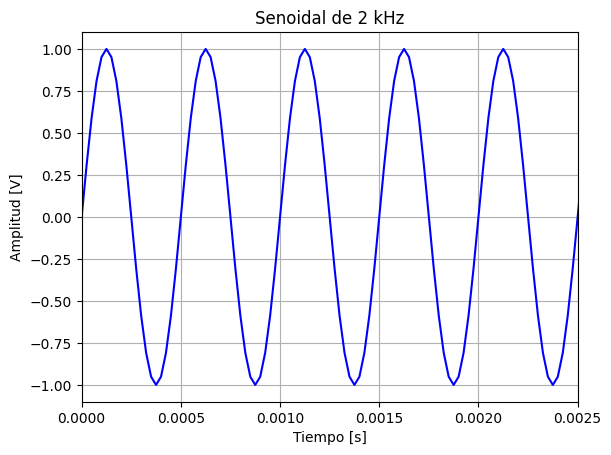

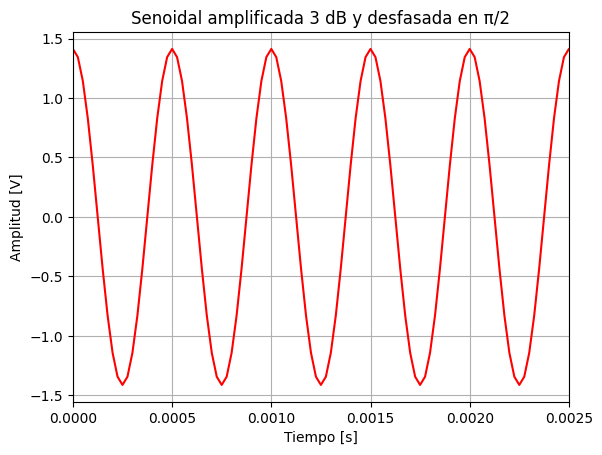

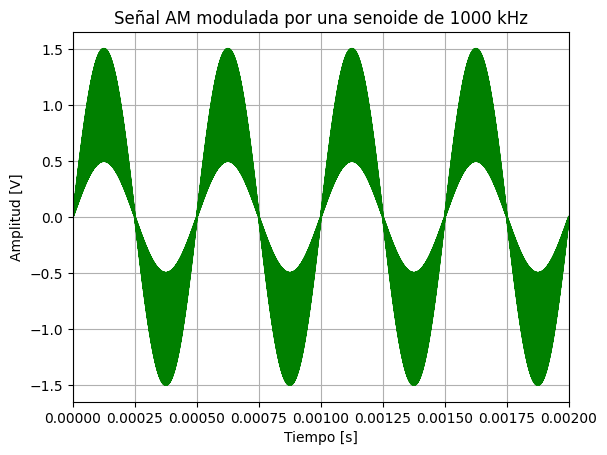

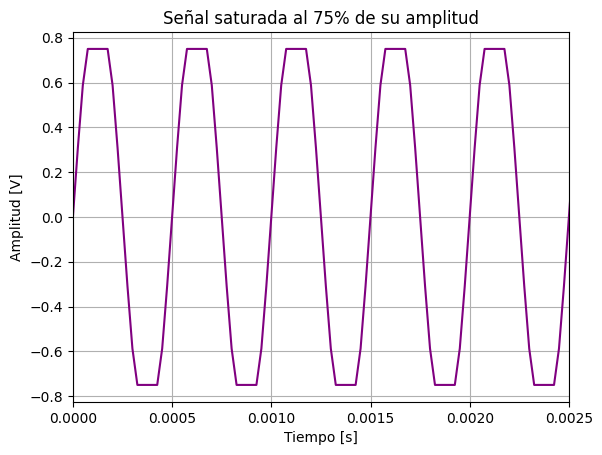

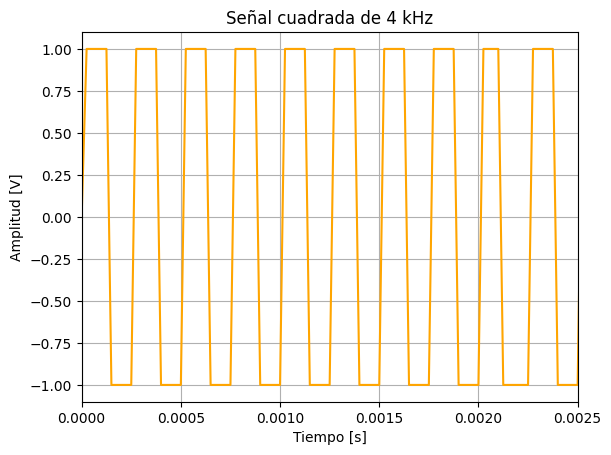

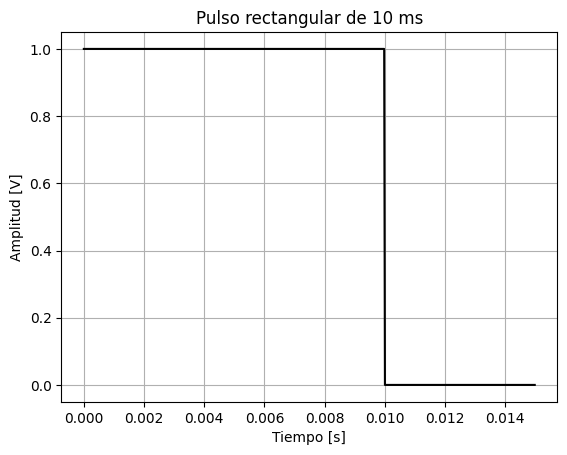

In [18]:

N = 800
fs1 = 40000   # Hz
vmax1 = 1
dc1 = 0
f1 = 2000     # 2 kHz
ph1 = 0


#  Señal sinusoidal de 2 kHz
t1, x1 = sen(vmax=vmax1, dc=dc1, ff=f1, ph=ph1, nn=N, fs=fs1)

plt.figure()
plt.plot(t1, x1, color='blue')
plt.title('Senoidal de 2 kHz')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.xlim(0, 0.0025)
plt.grid(True)

# Misma señal amplificada 3 dB y desfasada en pi/2

dB = 3
a = 10**(dB/20)   # ganancia en amplitud
vmax2 = vmax1 * a
ph2 = np.pi / 2

t2, x2 = sen(vmax=vmax2, dc=dc1, ff=f1, ph=ph2, nn=N, fs=fs1)

plt.figure()
plt.plot(t2, x2, color='red')
plt.title('Senoidal amplificada 3 dB y desfasada en π/2')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.xlim(0, 0.0025)
plt.grid(True)


# Misma señal modulada en amplitud por otra señal sinusoidal de frecuencia 1000 kHz
# Se tuvo que aumentar la frecuencia de muestreo para poder cumplir Nyquist ya que la señal para la modulacion es de 1MHz

fs3 = 40000000  # 10 MHz
N3 = 800000

Ac = 1
mu = 0.5           # 
fc = 2000          #
fm = 1_000_000     # 

t3, xm = sen(vmax=1, dc=0, ff=fm, ph=0, nn=N3, fs=fs3)
_, xc = sen(vmax=Ac, dc=0, ff=fc, ph=0, nn=N3, fs=fs3)

x3 = (1 + mu * xm) * xc

plt.figure()
plt.plot(t3, x3, color='green')
plt.title('Señal AM modulada por una senoide de 1000 kHz')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.xlim(0, 0.002)
plt.grid(True)

#  Misma señal con saturación al 75% de su amplitud
porcentaje = 0.75
vmax_clip = porcentaje * vmax1

t4, x4 = sen(vmax=vmax1, dc=dc1, ff=f1, ph=ph1, nn=N, fs=fs1)
x4 = np.clip(x4, -vmax_clip, vmax_clip)

plt.figure()
plt.plot(t4, x4, color='purple')
plt.title('Señal saturada al 75% de su amplitud')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.xlim(0, 0.0025)
plt.grid(True)

#  Señal cuadrada de 4 kHz
fcuad = 4000
t5, x5s = sen(vmax=vmax1, dc=dc1, ff=fcuad, ph=ph1, nn=N, fs=fs1)
x5 = np.sign(x5s)

plt.figure()
plt.plot(t5, x5, color='orange')
plt.title('Señal cuadrada de 4 kHz')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.xlim(0, 0.0025)
plt.grid(True)


# Pulso rectangular de 10 ms
ts = 1 / fs1

T_total = 15e-3
nn6 = int(T_total * fs1)
t6 = np.arange(nn6) * ts

T_pulso = 10e-3
n6 = int(T_pulso * fs1)

x6 = np.zeros(nn6)
x6[:n6] = 1

plt.figure()
plt.plot(t6, x6, color='black')
plt.title('Pulso rectangular de 10 ms')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True)

plt.show()

Ejercicio 2

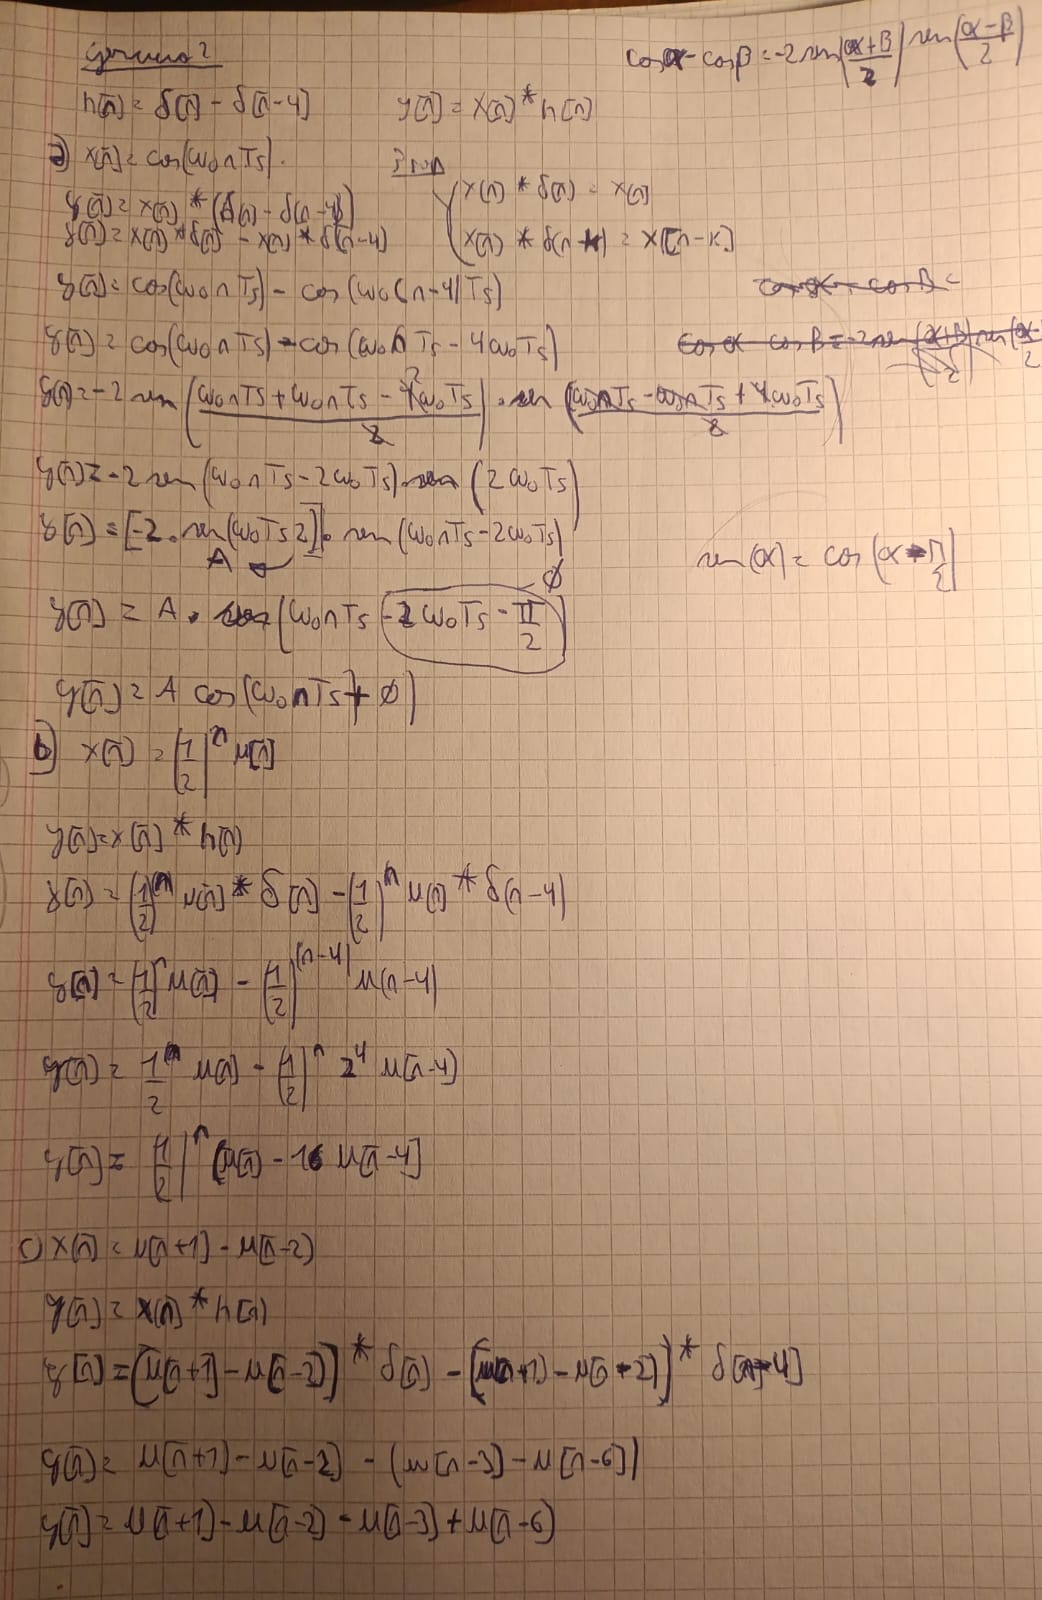

In [2]:
from IPython.display import Image, display

display(Image(filename=r'D:\Nueva carpeta\AyP\AyP\aps2.jpeg'))

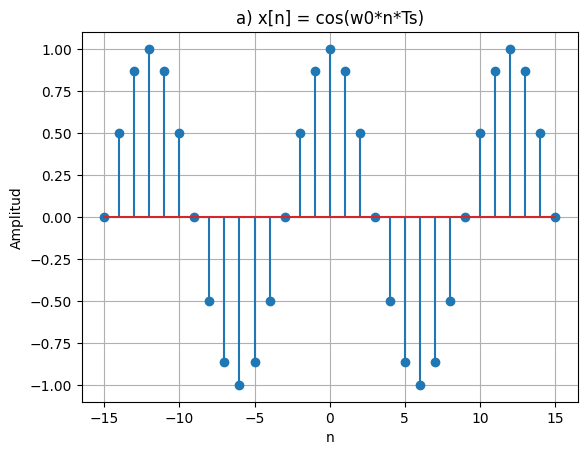

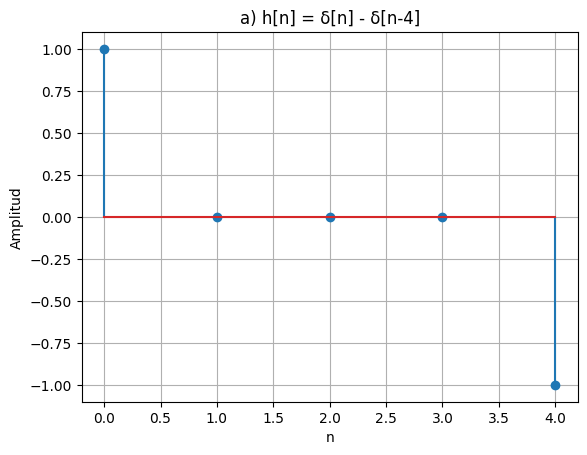

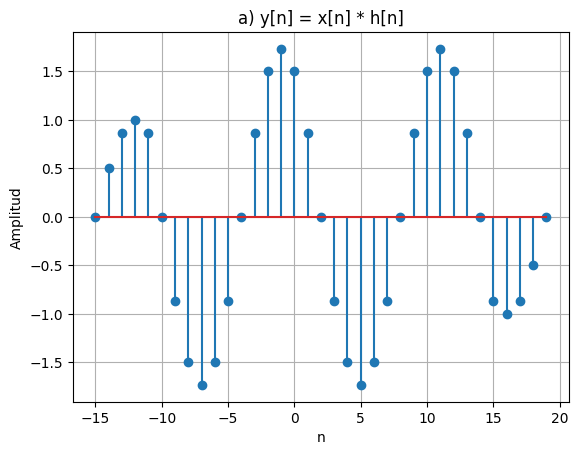

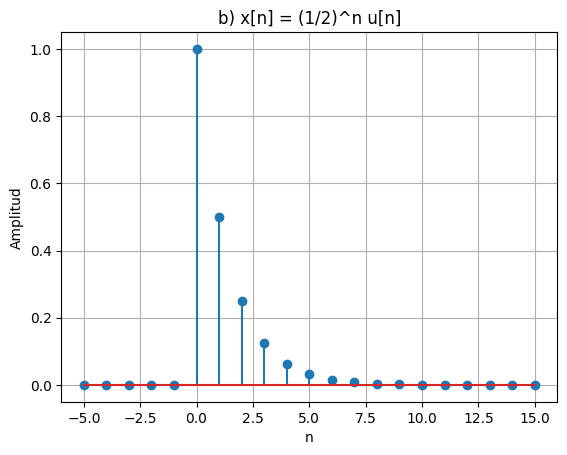

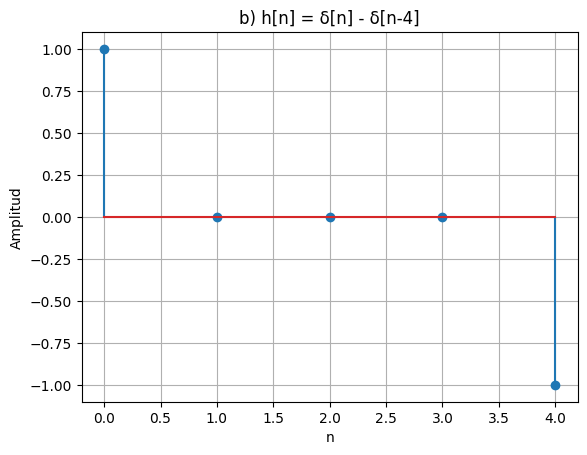

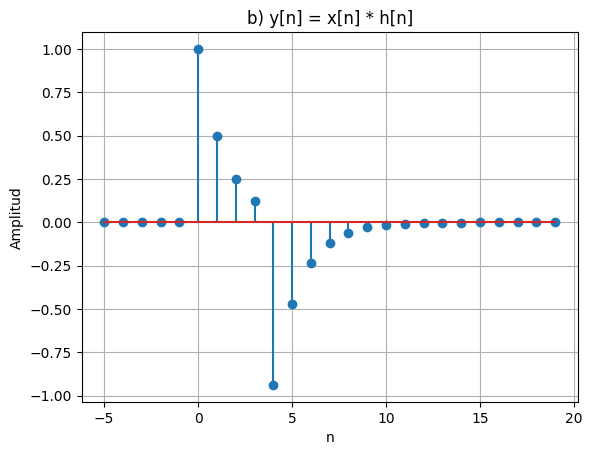

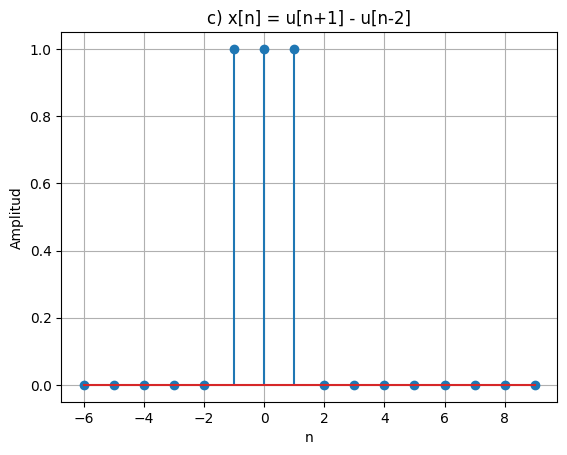

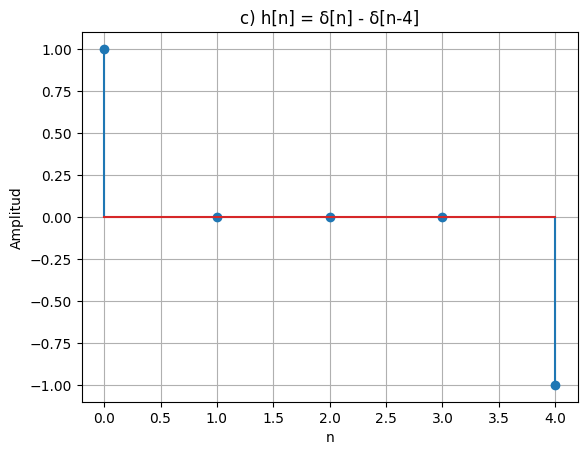

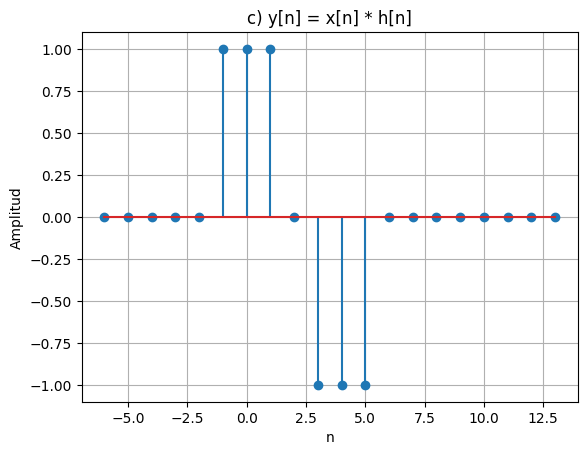

In [17]:

def u(n):
    return np.where(n >= 0, 1, 0)

# h[n] = δ[n] - δ[n-4]
nh = np.arange(0, 5)
h = np.zeros(len(nh))
h[0] = 1
h[4] = -1


# x[n] = cos(w0*n*Ts)
Ts = 1
w0 = np.pi / 6

na = np.arange(-15, 16)
xa = np.cos(w0 * na * Ts)

# Convolución con scipy
ya = sig.convolve(xa, h, mode='full')
nya = np.arange(na[0] + nh[0], na[-1] + nh[-1] + 1)

plt.figure()
plt.stem(na, xa)
plt.title('a) x[n] = cos(w0*n*Ts)')
plt.xlabel('n')
plt.ylabel('Amplitud')
plt.grid(True)

plt.figure()
plt.stem(nh, h)
plt.title('a) h[n] = δ[n] - δ[n-4]')
plt.xlabel('n')
plt.ylabel('Amplitud')
plt.grid(True)

plt.figure()
plt.stem(nya, ya)
plt.title('a) y[n] = x[n] * h[n]')
plt.xlabel('n')
plt.ylabel('Amplitud')
plt.grid(True)

# b) x[n] = (1/2)^n u[n]

nb = np.arange(-5, 16)
xb = (1/2)**nb * u(nb)

yb = sig.convolve(xb, h, mode='full')
nyb = np.arange(nb[0] + nh[0], nb[-1] + nh[-1] + 1)

plt.figure()
plt.stem(nb, xb)
plt.title('b) x[n] = (1/2)^n u[n]')
plt.xlabel('n')
plt.ylabel('Amplitud')
plt.grid(True)

plt.figure()
plt.stem(nh, h)
plt.title('b) h[n] = δ[n] - δ[n-4]')
plt.xlabel('n')
plt.ylabel('Amplitud')
plt.grid(True)

plt.figure()
plt.stem(nyb, yb)
plt.title('b) y[n] = x[n] * h[n]')
plt.xlabel('n')
plt.ylabel('Amplitud')
plt.grid(True)

# c) x[n] = u[n+1] - u[n-2]

nc = np.arange(-6, 10)
xc = u(nc + 1) - u(nc - 2)

yc = sig.convolve(xc, h, mode='full')
nyc = np.arange(nc[0] + nh[0], nc[-1] + nh[-1] + 1)

plt.figure()
plt.stem(nc, xc)
plt.title('c) x[n] = u[n+1] - u[n-2]')
plt.xlabel('n')
plt.ylabel('Amplitud')
plt.grid(True)

plt.figure()
plt.stem(nh, h)
plt.title('c) h[n] = δ[n] - δ[n-4]')
plt.xlabel('n')
plt.ylabel('Amplitud')
plt.grid(True)

plt.figure()
plt.stem(nyc, yc)
plt.title('c) y[n] = x[n] * h[n]')
plt.xlabel('n')
plt.ylabel('Amplitud')
plt.grid(True)

plt.show()

## Conclusiones

A partir de los gráficos obtenidos puede concluirse que las señales sintetizadas cumplen con las transformaciones pedidas y permiten observar claramente cómo distintas operaciones y valores modifican una señal original.
En primer lugar, la señal senoidal de 2 kHz se observa sin ningun problema, ya que se respeta Nyquist, y al amplificarla 3 dB y desfasarla en $π/2$, el gráfico muestra un aumento de amplitud, correspondiente a la ganancia aplicada, y un corrimiento temporal debido al desfase.
En la señal modulada en amplitud se ve que la amplitud de la portadora deja de ser constante y pasa a depender de la señal moduladora. Esto verifica el comportamiento esperado de una modulación AM.
En la señal saturada al 75% de su amplitud se observa un recorte de los picos positivos y negativos, la señal conserva su forma senoidal solo en la zona central, pero al superar cierto valor límite queda truncada.
La señal cuadrada de 4 kHz presenta únicamente dos niveles, positivo y negativo, lo que coincide con el comportamiento esperado de una onda cuadrada ideal.
En el pulso rectangular de 10 ms se observa una señal que permanece en nivel alto durante el intervalo definido y luego vuelve a cero.

Respecto de la convolución, en los tres casos se verifica el efecto del sistema definido por:
$$
h[n] = \delta[n] - \delta[n-4]
$$
Este sistema genera una salida de la forma:
$$
y[n] = x[n] - x[n-4]
$$
por lo tanto actúa restando a la señal original una copia retardada 4 muestras. En la primera parte, donde la entrada es cosenoidal, la salida conserva el carácter oscilatorio pero cambia su amplitud y fase, ya que surge de la diferencia entre dos cosenos desplazados. En la segunda parte, la salida resulta de restar dos exponenciales decrecientes desplazadas, lo cual produce un cambio abrupto a partir del instante en que aparece la versión retardada. En la ultima parte, como la entrada es un pulso rectangular discreto, la salida muestra un pulso positivo y luego otro negativo desplazado, lo que refleja directamente la estructura de diferencia impuesta por $h[n]$.
